# Import Models 

In [1]:
import os
import subprocess
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import NSGAIIISampler
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

C:\Users\hp\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Build the python script for simulation running 

In [7]:
ECLRUN_EXE = r"C:\ecl\macros\eclrun.exe"

BASE_DIR = r"C:\Users\hp\Desktop\Eclipse 1 optimisation approach"  # we did the simulation for TPE & NSGA on the same DATA file 

DATA_FILE_NAME = "Egg_Model_ECL.DATA"
SCHEDULE_FILE_NAME = "SCHEDULE_NEW.INC"
RSM_PATH = r"C:\Users\hp\Desktop\Eclipse 1 optimisation approach\EGG_MODEL_ECL.RSM"

In [8]:
def modify_files(params):
#____________________________________________________________
    sched_path = os.path.join(BASE_DIR, SCHEDULE_FILE_NAME)

    inj_map = {
        "INJECT1": params["inj_rate1"],
        "INJECT2": params["inj_rate2"],
        "INJECT3": params["inj_rate3"],
        "INJECT4": params["inj_rate4"],
        "INJECT5": params["inj_rate5"],
        "INJECT6": params["inj_rate6"],
        "INJECT7": params["inj_rate7"],
        "INJECT8": params["inj_rate8"],
    }

    with open(sched_path, "r") as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        stripped = line.strip()

        for well, rate in inj_map.items():
            if stripped.startswith(f"'{well}'") and "'RATE'" in stripped:
                parts = stripped.split()

                # Find RATE keyword index safely
                rate_idx = parts.index("'RATE'") + 1
                parts[rate_idx] = str(int(rate))

                line = " ".join(parts) + "\n"

        new_lines.append(line)

    with open(sched_path, "w") as f:
        f.writelines(new_lines)

#_____________________________________________________________
    data_path = os.path.join(BASE_DIR, DATA_FILE_NAME)

    prod_map = {
        "PROD1": params["BHP1"],
        "PROD2": params["BHP2"],
        "PROD3": params["BHP3"],
        "PROD4": params["BHP4"],
    }
    with open(data_path, "r") as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        stripped = line.strip()

        for well, bhp in prod_map.items():
            if stripped.startswith(f"'{well}'") and "'BHP'" in stripped:
                parts = stripped.split()
                parts[-1] = f"{int(bhp)}/"
                line = " ".join(parts) + "\n"

        new_lines.append(line)

    with open(data_path, "w") as f:
        f.writelines(new_lines)

In [9]:
def run_eclipse():
    cmd = [
        ECLRUN_EXE,
        "eclipse",
        DATA_FILE_NAME
    ]
    subprocess.run(cmd, cwd=BASE_DIR, check=True)
    
def extract_FOPT_FWPT_from_RSM(rsm_path):

    with open(rsm_path, "r") as f:
        lines = f.readlines()

    inside_summary = False
    fopt_idx = fwpt_idx = None

    for line in lines:

        if "SUMMARY OF RUN" in line:
            inside_summary = True
            fopt_idx = fwpt_idx = None
            continue

        if not inside_summary:
            continue

        tokens = line.split()
        if not tokens:
            continue

        # Detect column headers
        if fopt_idx is None and "FOPT" in tokens and "FWPT" in tokens:
            fopt_idx = tokens.index("FOPT")
            fwpt_idx = tokens.index("FWPT")
            continue

        if fopt_idx is None:
            continue

        # ✅ Only data rows have numeric TIME
        if not tokens[0][0].isdigit():
            continue
        if float(tokens[0]) == 3600.0:
            return float(tokens[fopt_idx]), float(tokens[fwpt_idx])

# Define the TPE objective function

In [10]:
def objective(trial):

    # ---------------------------------------------
    # 1. TPE parameter suggestions
    # ---------------------------------------------
    params = {
        "BHP1": trial.suggest_int("BHP1", 150, 390),
        "BHP2": trial.suggest_int("BHP2", 150, 390),
        "BHP3": trial.suggest_int("BHP3", 150, 390),
        "BHP4": trial.suggest_int("BHP4", 150, 390),
        "inj_rate1": trial.suggest_int("inj_rate1", 50, 400),
        "inj_rate2": trial.suggest_int("inj_rate2", 50, 400),
        "inj_rate3": trial.suggest_int("inj_rate3", 50, 400),
        "inj_rate4": trial.suggest_int("inj_rate4", 50, 400),
        "inj_rate5": trial.suggest_int("inj_rate5", 50, 400),
        "inj_rate6": trial.suggest_int("inj_rate6", 50, 400),
        "inj_rate7": trial.suggest_int("inj_rate7", 50, 400),
        "inj_rate8": trial.suggest_int("inj_rate8", 50, 400),
    }

    # ---------------------------------------------
    # 2. Modify Eclipse input files
    # ---------------------------------------------
    modify_files(params)

    # ---------------------------------------------
    # 3. Run Eclipse
    # ---------------------------------------------
    try:
        run_eclipse()
    except subprocess.CalledProcessError:
        # Penalize failed runs
        return -1e12, 1e12

    # ---------------------------------------------
    # 4. Read results
    # ---------------------------------------------
    fopt, fwpt = extract_FOPT_FWPT_from_RSM(
        RSM_PATH
    )

    # ---------------------------------------------
    # 5. Multi-objective return
    # ---------------------------------------------
    return fopt , fwpt

# TPE optimization running

In [11]:
sampler1 = optuna.samplers.TPESampler(
    n_startup_trials=42,
    multivariate=False,
    seed=42)

study1 = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=sampler1,
    study_name="ECLIPSE_SUM_DELTA_FOPT_FWPT"
)

study1.optimize(objective, n_trials=300, show_progress_bar=False)

[I 2026-07-31 19:40:49,810] A new study created in memory with name: ECLIPSE_SUM_DELTA_FOPT_FWPT
[I 2026-07-31 19:42:01,353] Trial 0 finished with values: [542456.4, 5351730.0] and parameters: {'BHP1': 240, 'BHP2': 379, 'BHP3': 326, 'BHP4': 294, 'inj_rate1': 104, 'inj_rate2': 104, 'inj_rate3': 70, 'inj_rate4': 354, 'inj_rate5': 260, 'inj_rate6': 298, 'inj_rate7': 57, 'inj_rate8': 390}. 
[I 2026-07-31 19:43:34,824] Trial 1 finished with values: [538358.4, 4629445.0] and parameters: {'BHP1': 350, 'BHP2': 201, 'BHP3': 193, 'BHP4': 194, 'inj_rate1': 156, 'inj_rate2': 234, 'inj_rate3': 201, 'inj_rate4': 152, 'inj_rate5': 264, 'inj_rate6': 98, 'inj_rate7': 152, 'inj_rate8': 178}. 
[I 2026-07-31 19:45:54,015] Trial 2 finished with values: [541525.1, 6195296.0] and parameters: {'BHP1': 259, 'BHP2': 339, 'BHP3': 198, 'BHP4': 273, 'inj_rate1': 257, 'inj_rate2': 66, 'inj_rate3': 263, 'inj_rate4': 109, 'inj_rate5': 72, 'inj_rate6': 383, 'inj_rate7': 388, 'inj_rate8': 333}. 
[I 2026-07-31 19:47:27,

# Optimization results

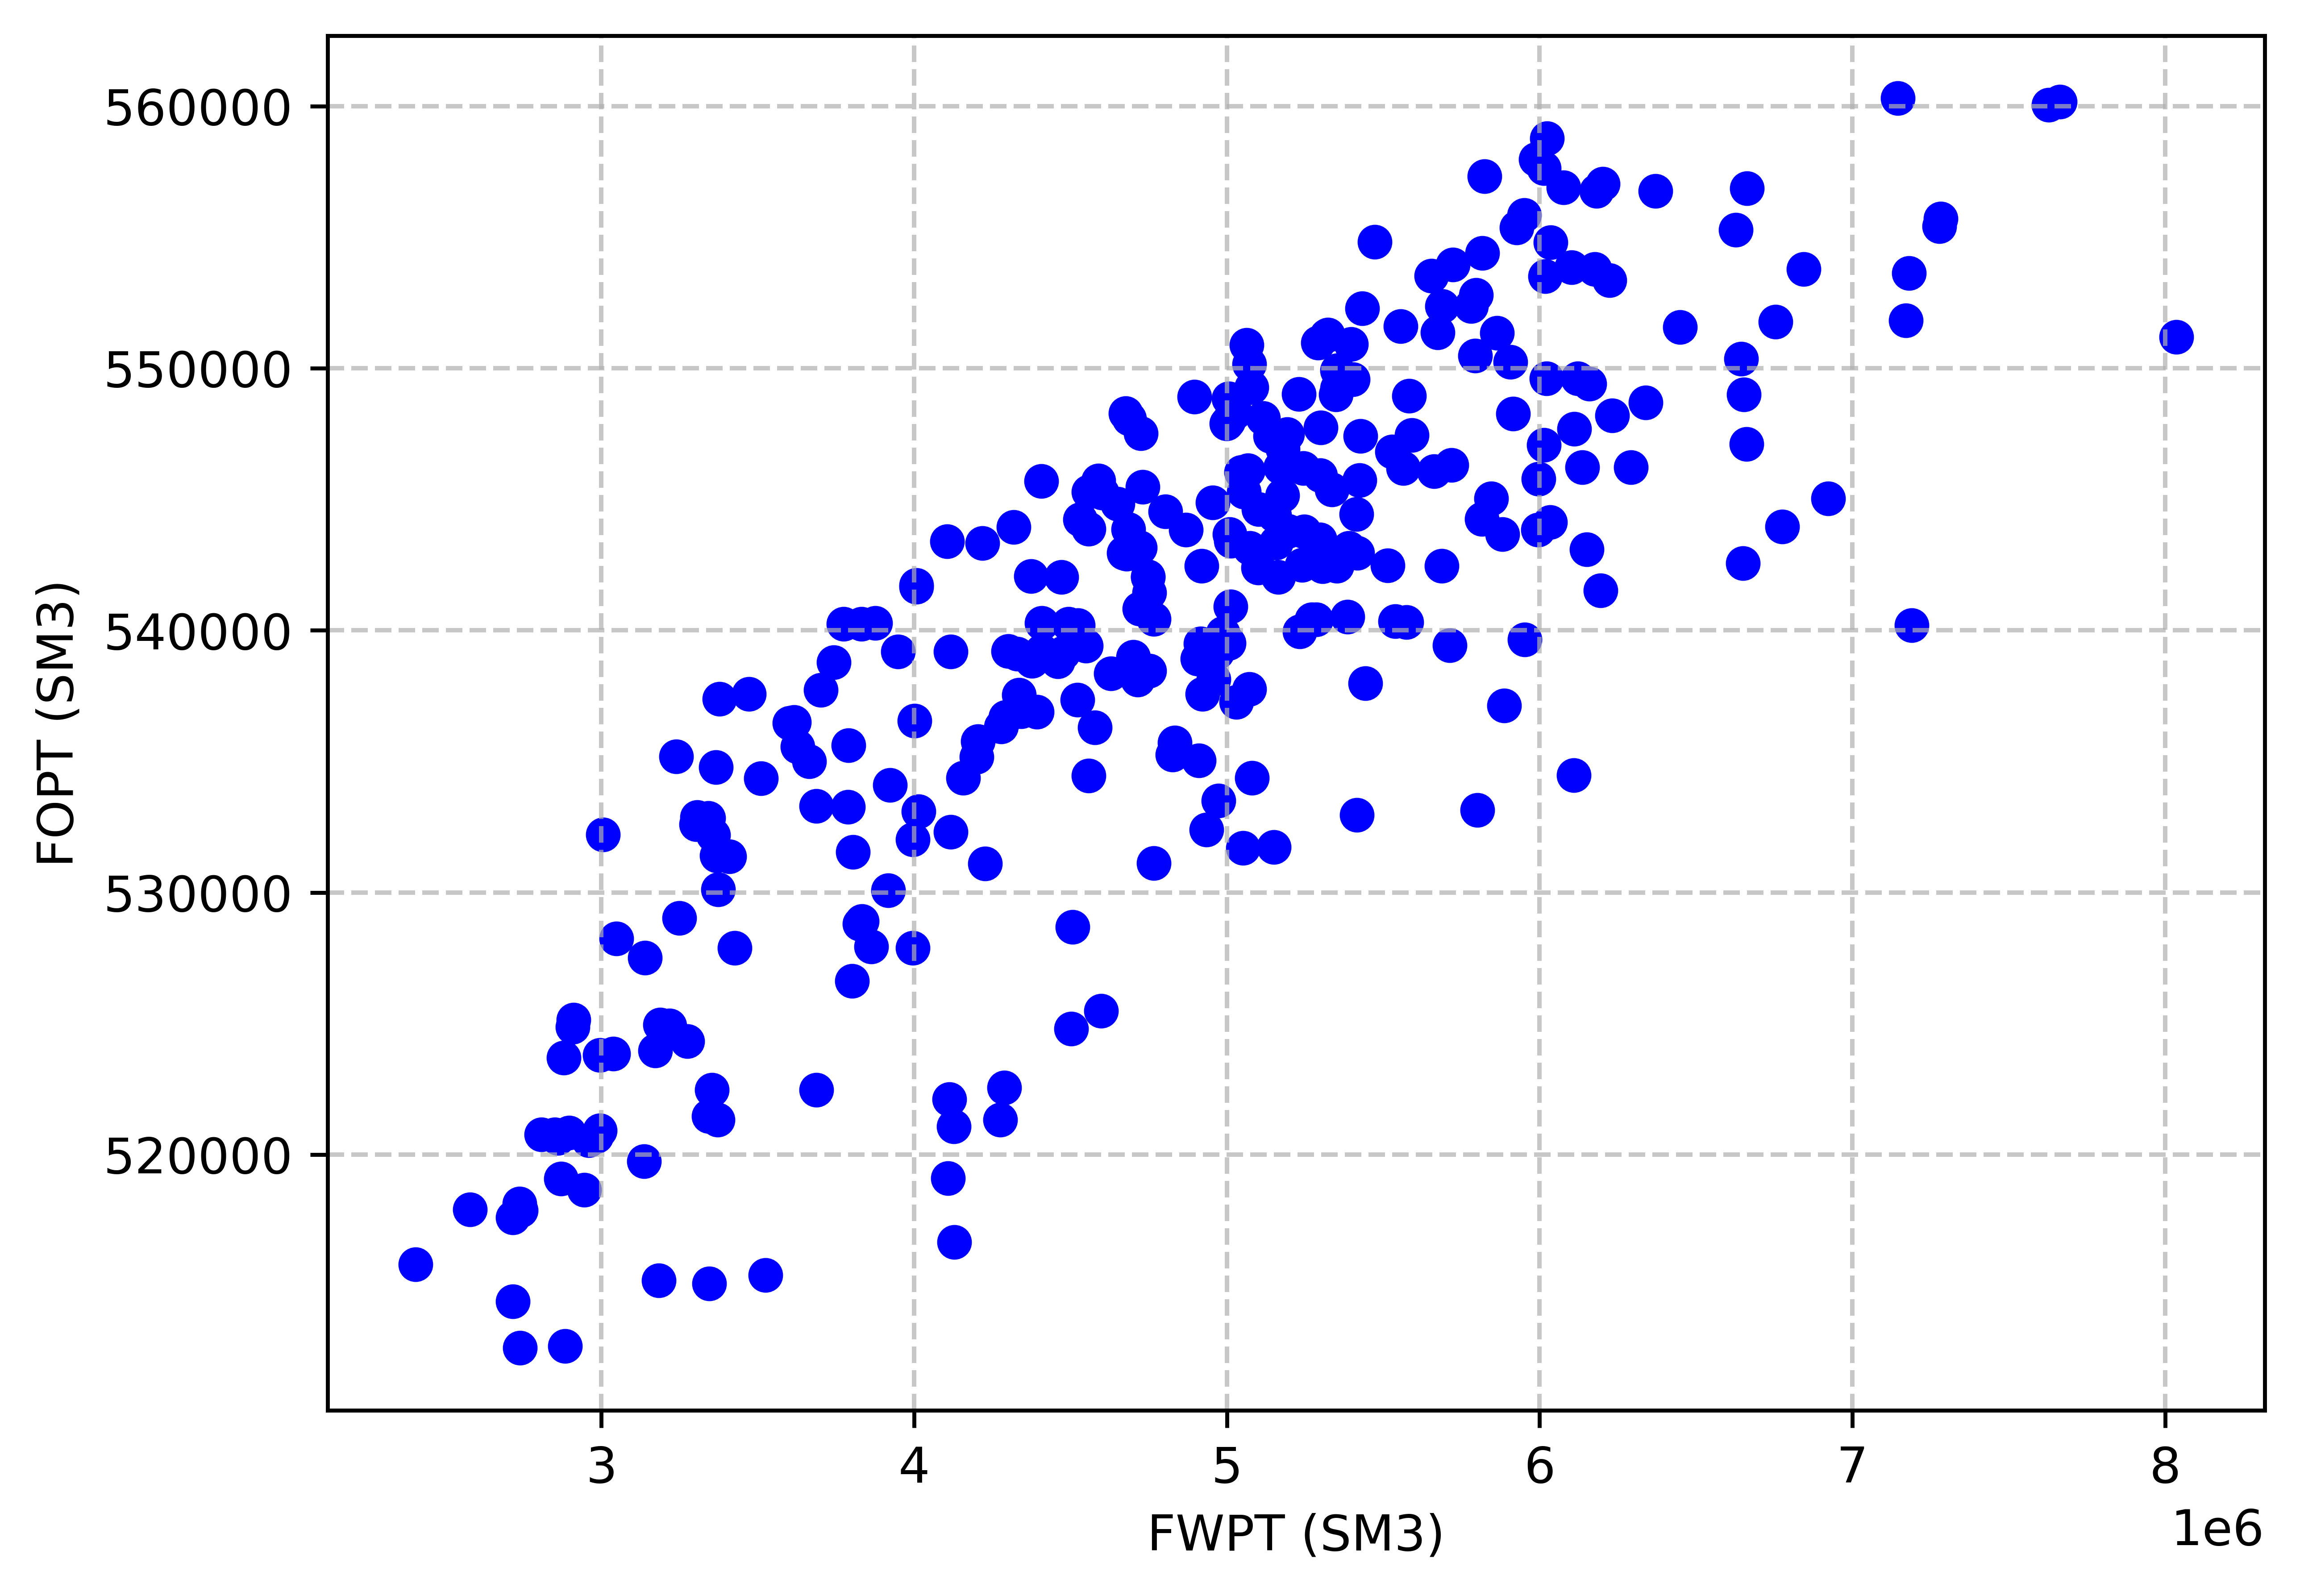

In [12]:
pareto_trials = study1.best_trials
fopts = [t.values[0] for t in study1.trials if t.values is not None]
fwpts = [t.values[1] for t in study1.trials if t.values is not None]

plt.figure(figsize=(7,5),dpi=800)
plt.scatter(fwpts, fopts, c='blue')
plt.xlabel("FWPT (SM3)")
plt.ylabel("FOPT (SM3)")
plt.grid(True, which="major", linestyle="--", linewidth=0.9, alpha=0.7)
plt.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.4)
plt.show()

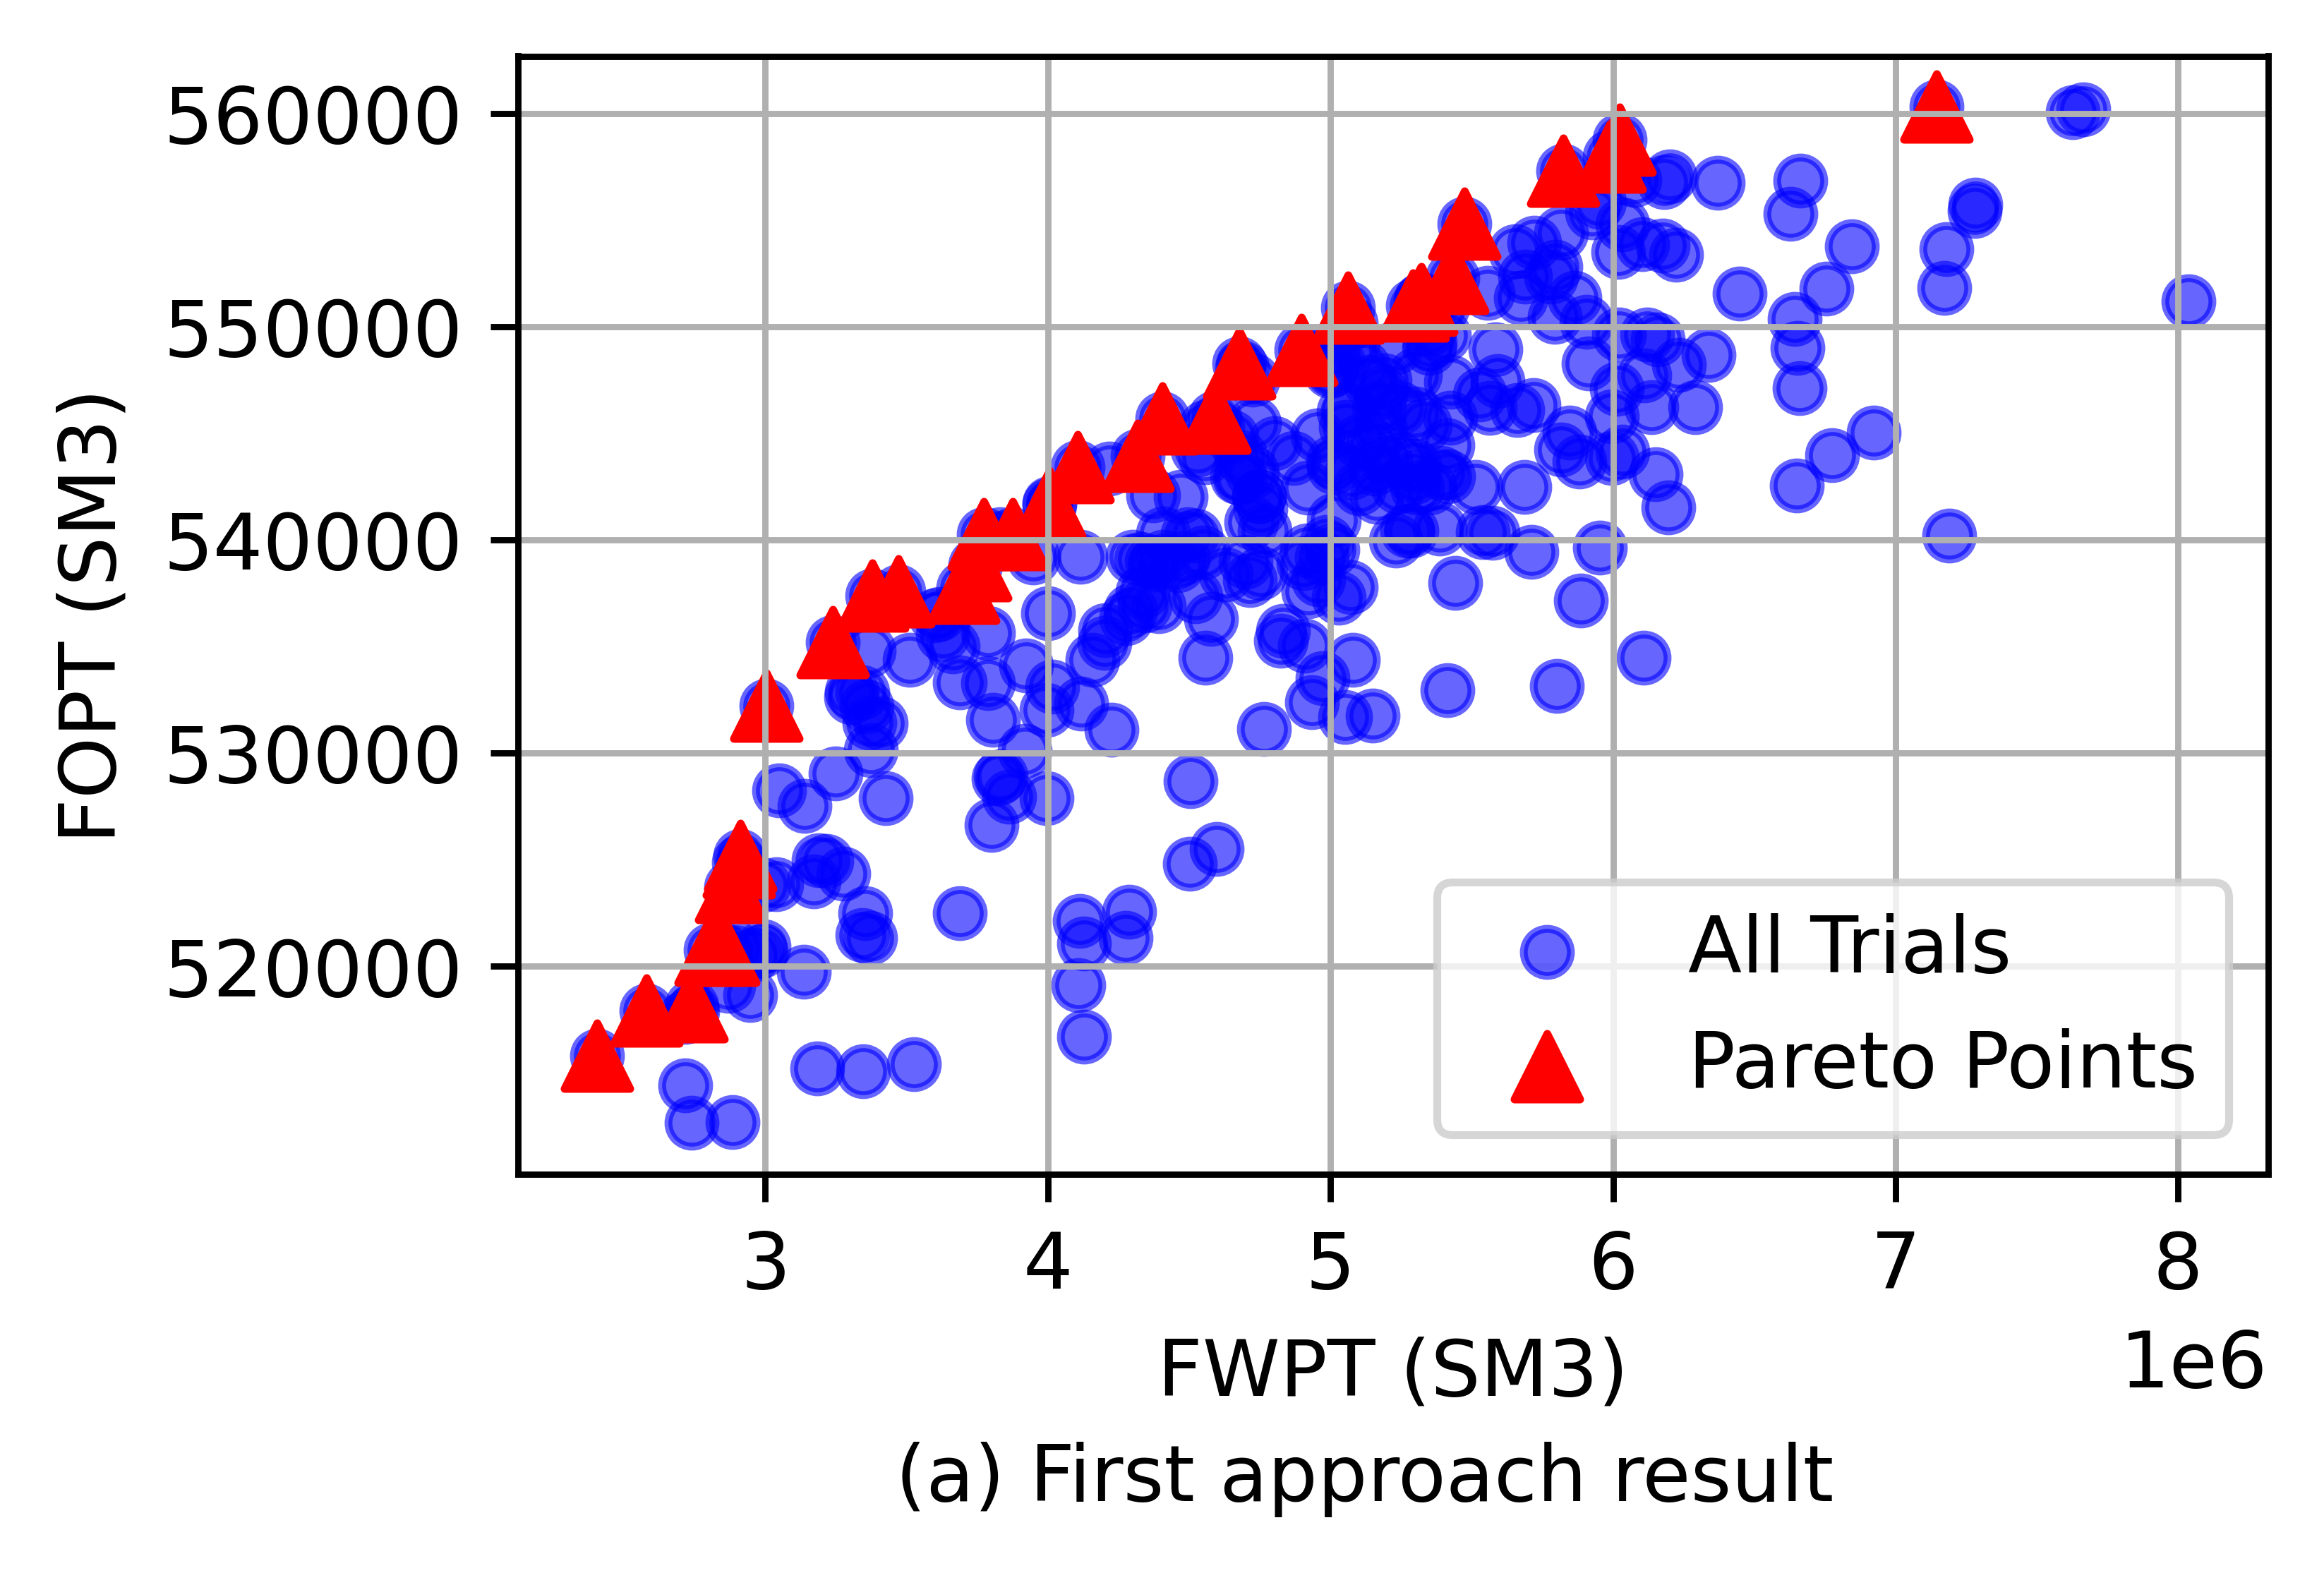

In [16]:
fopts = [t.values[0] for t in study1.trials if t.values is not None]
fwpts = [t.values[1] for t in study1.trials if t.values is not None]

# --- Pareto optimal trials ---
pareto_trials = study1.best_trials
pareto_fopts = [t.values[0] for t in pareto_trials]
pareto_fwpts = [t.values[1] for t in pareto_trials]

# --- Sort Pareto points by FWPT (minimization axis) ---
pareto_points = sorted(zip(pareto_fwpts, pareto_fopts))
pareto_fwpts_sorted, pareto_fopts_sorted = zip(*pareto_points)

fig, ax = plt.subplots(figsize=(4, 3), dpi=800)

# All solutions
ax.scatter(fwpts, fopts, color='blue', alpha=0.6, label='All Trials')

# Pareto points
ax.scatter(
    pareto_fwpts_sorted,
    pareto_fopts_sorted,
    color='red',
    marker='^',
    s=70,
    label='Pareto Points'
)

ax.set_xlabel("FWPT (SM3)")
ax.set_ylabel("FOPT (SM3)")
ax.legend()
ax.grid(True)

# Leave space at the bottom
plt.subplots_adjust(bottom=0.22)

# Add panel label below the figure
fig.text(
    0.5, 0.04,
    "(a) First approach result",
    ha="center",
    va="center",
    fontsize=10
)

plt.show()

In [29]:
FOPT = np.array([t.values[0] for t in pareto_trials])
FWPT = np.array([t.values[1] for t in pareto_trials])

# normalize
FOPT_n = (FOPT - FOPT.min())/(FOPT.max()-FOPT.min())
FWPT_n = (FWPT - FWPT.min())/(FWPT.max()-FWPT.min())

dist = np.sqrt((1 - FOPT_n)**2 + FWPT_n**2)

best_idx = np.argmin(dist)
best_trial = pareto_trials[best_idx]

print("\nSelected Best Solution:\n")
print("Trial:", best_trial.number)
print("FOPT:", best_trial.values[0])
print("FWPT:", best_trial.values[1])
print("Parameters:", best_trial.params)


Selected Best Solution:

Trial: 121
FOPT: 543399.8
FWPT: 4105474.0
Parameters: {'BHP1': 337, 'BHP2': 299, 'BHP3': 300, 'BHP4': 208, 'inj_rate1': 335, 'inj_rate2': 52, 'inj_rate3': 130, 'inj_rate4': 59, 'inj_rate5': 110, 'inj_rate6': 339, 'inj_rate7': 69, 'inj_rate8': 197}


In [30]:
print("\nPareto Front Table\n")
print("Trial\tFOPT\tFWPT")

for trial in pareto_trials:
    print(f"{trial.number}\t{trial.values[0]:.2f}\t{trial.values[1]:.2f}")


Pareto Front Table

Trial	FOPT	FWPT
99	551243.70	5318491.00
108	541661.80	4006628.00
119	545717.10	4589998.00
121	543399.80	4105474.00
125	543941.10	4317610.00
128	560304.80	7145056.00
131	545695.80	4406054.00
134	550974.30	5292198.00
140	552284.10	5432694.00
143	548916.20	4896096.00
167	537733.50	3701111.00
171	538788.40	3743232.00
178	551276.90	5322482.00
190	517906.20	2579992.00
194	518124.30	2738132.00
204	520764.80	2850668.00
207	524872.50	2907792.00
211	520763.80	2807577.00
216	540275.40	3875092.00
219	541728.90	4006716.00
232	515811.30	2405720.00
238	550890.10	5062894.00
248	525153.10	2911018.00
256	532218.00	3004937.00
257	535184.10	3239549.00
258	537387.10	3377690.00
259	537576.80	3471231.00
273	558763.90	6023649.00
274	554825.10	5473337.00
277	557315.10	5823571.00
285	557965.60	5988383.00
286	548285.40	4676986.00
289	540252.20	3774210.00
297	523705.40	2880091.00


In [31]:
print("\nPareto Optimal Solutions:\n")

for i, trial in enumerate(pareto_trials):
    print(f"Solution {i+1}")
    print("Trial number:", trial.number)
    print("FOPT (maximize):", trial.values[0])
    print("FWPT (minimize):", trial.values[1])
    print("Parameters:", trial.params)
    print("-" * 40)


Pareto Optimal Solutions:

Solution 1
Trial number: 99
FOPT (maximize): 551243.7
FWPT (minimize): 5318491.0
Parameters: {'BHP1': 300, 'BHP2': 309, 'BHP3': 303, 'BHP4': 174, 'inj_rate1': 356, 'inj_rate2': 387, 'inj_rate3': 112, 'inj_rate4': 50, 'inj_rate5': 183, 'inj_rate6': 351, 'inj_rate7': 65, 'inj_rate8': 127}
----------------------------------------
Solution 2
Trial number: 108
FOPT (maximize): 541661.8
FWPT (minimize): 4006628.0
Parameters: {'BHP1': 304, 'BHP2': 328, 'BHP3': 287, 'BHP4': 186, 'inj_rate1': 317, 'inj_rate2': 99, 'inj_rate3': 105, 'inj_rate4': 69, 'inj_rate5': 140, 'inj_rate6': 308, 'inj_rate7': 72, 'inj_rate8': 153}
----------------------------------------
Solution 3
Trial number: 119
FOPT (maximize): 545717.1
FWPT (minimize): 4589998.0
Parameters: {'BHP1': 300, 'BHP2': 156, 'BHP3': 380, 'BHP4': 177, 'inj_rate1': 376, 'inj_rate2': 50, 'inj_rate3': 109, 'inj_rate4': 60, 'inj_rate5': 199, 'inj_rate6': 334, 'inj_rate7': 98, 'inj_rate8': 200}
--------------------------

# Best optimal with contraint

In [19]:
FWPT_max = 6200000  # constraint on water production

# Extract Pareto values
fopt = np.array([t.values[0] for t in pareto_trials])
fwpt = np.array([t.values[1] for t in pareto_trials])

# ===============================
# Apply constraint (FWPT <= limit)
# ===============================
valid_indices = [i for i, fw in enumerate(fwpt) if fw <= FWPT_max]

if valid_indices:

    # Select best FOPT among valid ones
    best_idx = max(valid_indices, key=lambda i: fopt[i])
    best_trial_constraint = pareto_trials[best_idx]

    # --- Extract values ---
    best_fopt = best_trial_constraint.values[0]
    best_fwpt = best_trial_constraint.values[1]
    params = best_trial_constraint.params

    # --- Separate BHP and Injection rates ---
    bhp_params = {k: v for k, v in params.items() if "BHP" in k}
    inj_params = {k: v for k, v in params.items() if "inj" in k.lower()}

    # --- Print results ---
    print("========== CONSTRAINED OPTIMAL SOLUTION ==========")
    print(f"Trial Number : {best_trial_constraint.number}")
    print(f"FOPT         : {best_fopt}")
    print(f"FWPT         : {best_fwpt}")

    print("\n--- BHP Parameters ---")
    for k, v in bhp_params.items():
        print(f"{k}: {v}")

    print("\n--- Injection Rate Parameters ---")
    for k, v in inj_params.items():
        print(f"{k}: {v}")

else:
    print("No Pareto solution satisfies the FWPT constraint.")

========== CONSTRAINED OPTIMAL SOLUTION ==========
Trial Number : 273
FOPT         : 558763.9
FWPT         : 6023649.0

--- BHP Parameters ---
BHP1: 375
BHP2: 204
BHP3: 283
BHP4: 384

--- Injection Rate Parameters ---
inj_rate1: 369
inj_rate2: 69
inj_rate3: 360
inj_rate4: 86
inj_rate5: 66
inj_rate6: 374
inj_rate7: 141
inj_rate8: 363
